In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv('data/urls.csv')
print("\nLabel Distribution")
print(df['label'].value_counts())
print("\nLabel Percentage")
print(df['label'].value_counts(normalize=True)*100)


Label Distribution
label
legitimate    129420
phishing      123678
Name: count, dtype: int64

Label Percentage
label
legitimate    51.134343
phishing      48.865657
Name: proportion, dtype: float64


In [30]:
print("Missing Values")
print(df.isnull().sum())
print("Duplicate URLs:",df['url'].duplicated().sum())
print("Basic Statistics")
df['url_length']=df['url'].apply(len)
print(df['url_length'].describe())

Missing Values
url      0
label    0
dtype: int64
Duplicate URLs: 0
Basic Statistics
count    253098.000000
mean         59.988502
std          88.064423
min          11.000000
25%          35.000000
50%          49.000000
75%          69.000000
max       25523.000000
Name: url_length, dtype: float64


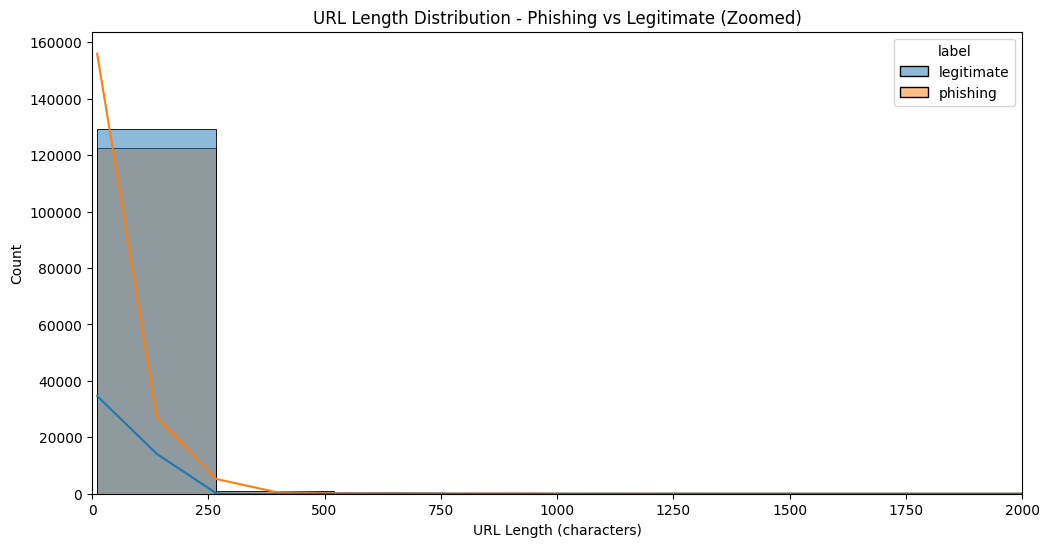

In [31]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='url_length', hue='label', bins=100, kde=True)
plt.title('URL Length Distribution - Phishing vs Legitimate (Zoomed)')
plt.xlabel('URL Length (characters)')
plt.ylabel('Count')
plt.xlim(0, 2000)   # this makes the difference crystal clear
plt.show()

URL Length Statistics by Label
               count       mean         std   min   25%   50%   75%      max
label                                                                       
legitimate  129420.0  55.650950   26.783797  11.0  38.0  51.0  68.0    651.0
phishing    123678.0  64.527434  122.800003  12.0  32.0  46.0  72.0  25523.0


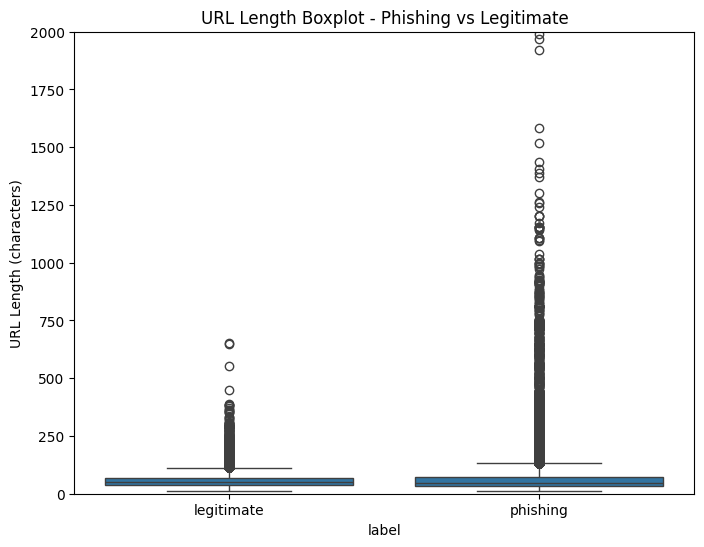

In [32]:
# Cell: Statistical comparison
print("URL Length Statistics by Label")
print(df.groupby('label')['url_length'].describe())

# Cell: Boxplot (better for seeing median & outliers)
plt.figure(figsize=(8, 6))
sns.boxplot(x='label', y='url_length', data=df)
plt.title('URL Length Boxplot - Phishing vs Legitimate')
plt.ylabel('URL Length (characters)')
plt.ylim(0, 2000)   # zoom in to see the real difference
plt.show()

In [33]:
print(df.dtypes)
df['Label'] = df['label'].map({'legitimate': 0, 'phishing': 1})
print("\nFinal Label distribution:")
print(df['Label'].value_counts())
df.to_csv('data/cleaned_phishing_urls.csv', index=False)

url             str
label           str
url_length    int64
dtype: object

Final Label distribution:
Label
0    129420
1    123678
Name: count, dtype: int64


In [34]:
# Cell 1
import pandas as pd
from features import extract_features   # ← this imports your file

df = pd.read_csv('data/cleaned_phishing_urls.csv')
print("Loaded", len(df), "URLs")

# Cell 2 - Test on one URL
print("Testing first URL...")
print(extract_features(df['url'].iloc[0]))

# Cell 3 - Extract features for ALL rows (takes ~1-2 minutes)
print("Extracting features for entire dataset...")
feature_list = df['url'].apply(extract_features)
features_df = pd.DataFrame(feature_list.tolist())
features_df['Label'] = df['Label']

print(features_df.head())
print("Features shape:", features_df.shape)

# Cell 4 - Save
features_df.to_csv('data/features.csv', index=False)
print("✅ All features saved to data/features.csv !")

Loaded 253098 URLs
Testing first URL...
{'url_length': 27, 'num_dots': 2, 'has_at': 0, 'has_double_slash': 0, 'has_https': 1, 'has_ip': 0, 'num_subdomains': 2, 'is_shortened': 0, 'suspicious_words': 0, 'domain_length': 19, 'num_special_chars': 0, 'url_entropy': 3.8562}
Extracting features for entire dataset...
   url_length  num_dots  has_at  has_double_slash  has_https  has_ip  \
0          27         2       0                 0          1       0   
1          34         3       0                 0          0       1   
2          51         4       0                 0          1       0   
3         175         2       0                 0          1       0   
4          79         4       0                 0          1       0   

   num_subdomains  is_shortened  suspicious_words  domain_length  \
0               2             0                 0             19   
1               3             0                 0             12   
2               3             0                 0  

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

df = pd.read_csv('data/features.csv')
print("Loaded shape:", df.shape)
print(df.head(3))

X = df.drop('Label', axis=1)   # all features
y = df['Label']                # 0 = legitimate, 1 = phishing

Loaded shape: (253098, 13)
   url_length  num_dots  has_at  has_double_slash  has_https  has_ip  \
0          27         2       0                 0          1       0   
1          34         3       0                 0          0       1   
2          51         4       0                 0          1       0   

   num_subdomains  is_shortened  suspicious_words  domain_length  \
0               2             0                 0             19   
1               3             0                 0             12   
2               3             0                 0             20   

   num_special_chars  url_entropy  Label  
0                  0       3.8562      0  
1                  0       3.9620      1  
2                  2       3.9654      0  


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (202478, 12)
Testing set: (50620, 12)


In [ ]:
model = RandomForestClassifier(
    n_estimators=500,      # number of trees
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

print("Training model")
model.fit(X_train, y_train)
print("✅ Model training completed!")

Training model
✅ Model training completed!


In [38]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

print("\nAccuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba), 4))

=== Classification Report ===
              precision    recall  f1-score   support

  Legitimate       0.92      0.95      0.93     25884
    Phishing       0.95      0.91      0.93     24736

    accuracy                           0.93     50620
   macro avg       0.93      0.93      0.93     50620
weighted avg       0.93      0.93      0.93     50620


Accuracy: 93.17 %
ROC-AUC Score: 0.9795


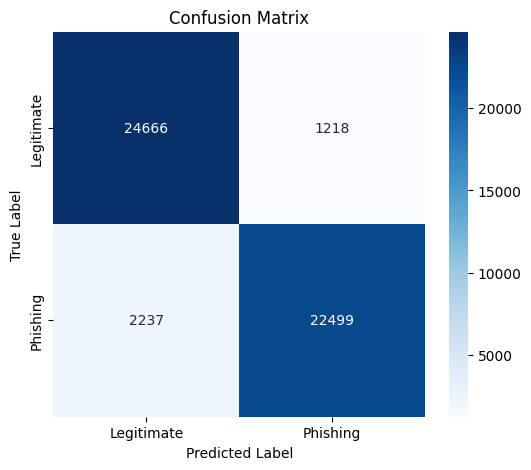

In [39]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

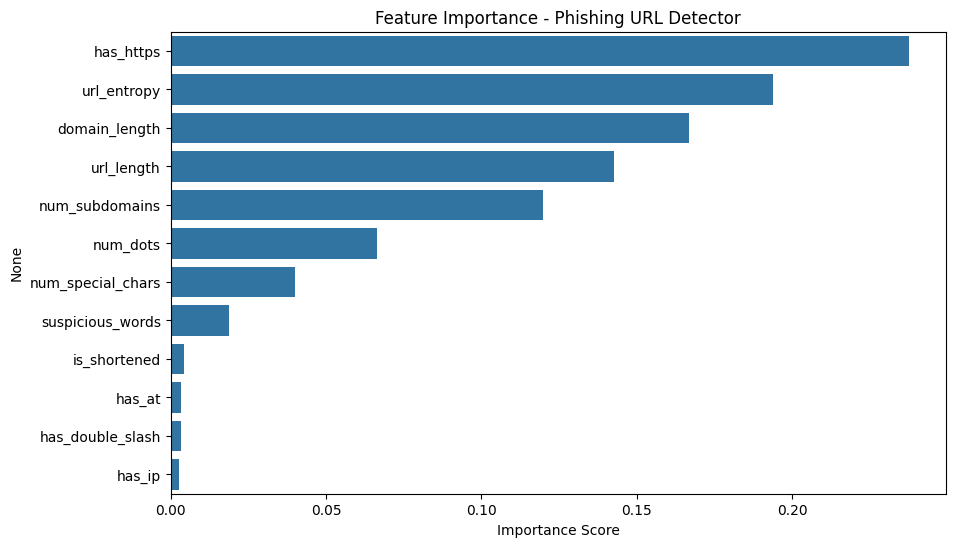


Top 5 most important features:
has_https         0.237570
url_entropy       0.193786
domain_length     0.166994
url_length        0.142627
num_subdomains    0.119840
dtype: float64


In [40]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance - Phishing URL Detector')
plt.xlabel('Importance Score')
plt.show()

print("\nTop 5 most important features:")
print(importances.head(5))

In [41]:
joblib.dump(model, 'phishing_model.pkl')
print("✅ Model saved as phishing_model.pkl")

✅ Model saved as phishing_model.pkl
